# <font style="font-family:roboto;color:#455e6c"> Validation of Interatomic Potentials </font>  

<div class="admonition note" name="html-admonition" style="background:#e3f2fd; padding: 10px">
<font style="font-family:roboto;color:#455e6c"> <b> DPG Tutorial: Automated Workflows and Machine Learning for Materials Science Simulations </b> </font> </br>
<font style="font-family:roboto;color:#455e6c"> 8 March 2026 </font> </br> </br>
Sriram Anand, Prabhath Chilakalapudi, Haitham Gaafer, Marvin Poul, Jan Janssen, Jörg Neugebauer </br>
<i> Max Planck Institute for Sustainable Materials </i></br>
</br>
Sarath Menon, Minaam Qamar, Ralf Drautz </br>
<i> Ruhr-Universität Bochum </i></br>
</br>
Tilmann Hickel </br>
<i> Bundesanstalt für Materialforschung und -prüfung </i></br>
</div>

<div class="admonition note" name="html-admonition" style="background: #FFEDD1; padding: 10px">
<p class="title"><b>Task</b></p>
Build a workflow to <code>iterate</code> over different (hydrostatic) strain states and get energy of the system.
To break it down, we need to
<ol>
    <li>Construct a set of structures that span different volumes
        <ul>
            <li>Construct the initial crystal</li>
            <li>Create an array of strains</li>
            <li>Apply the strains</li>
        </ul>
        <b>Simpler to change the volume by altering the lattice parameter</b>
    </li>
    Hint: Use the <code>IterateToDataframe</code> node
    <li>Calculate the energy at each volume
        <ul>
            <li>Loop over each strained structure</li>
            <li>Run a static single-point energy calculation, so that the volume isn't changed</li>
            <li>Collect the resulting energy for each structure</li>
        </ul>
    </li>
    Which node should we use?  <code>SinglePointStatic</code> or <code>Relax</code> ?
    <li>Gather the results into a usable format
        <ul>
            <li>Extract the volume from each structure</li>
            <li>Pair each volume with its corresponding energy to form (V, E) data points</li>
        </ul>
    </li>
    <li>Fit an equation of state (EOS) to the (V, E) data
        <ul>
            <li>Choose an EOS model (e.g., Birch-Murnaghan)</li>
            <li>Fit the model to extract equilibrium volume V&#8320;, cohesive energy E&#8320;, and bulk modulus B&#8320;</li>
        </ul>
    </li>
    <li>Visualize the results
        <ul>
            <li>Plot the raw (V, E) data points</li>
            <li>Overlay the fitted EOS curve</li>
            <li>Annotate the plot with the extracted quantities</li>
        </ul>
    </li>
</ol>
</div>

In [1]:
from core import Workflow, as_function_node
from core.gui import PyironFlow, GUILayout
from pyiron_nodes.atomistic.calculator.optimize import GenericOptimizerSettings
from pyiron_nodes.atomistic.property.bulk import FitBirchMurnaghanEOS, PlotEVCurve
from pyiron_nodes.atomistic.engine.grace import GRACE
from pyiron_nodes.atomistic.engine.ace import Ace
from pyiron_nodes.atomistic.structure.build import Bulk


from pyiron_nodes.basic.math import Linspace
from pyiron_nodes.basic.loop import IterToDataFrame

from pyiron_nodes.atomistic.calculator.optimize import SinglepointStatic 
from pyiron_nodes.basic.file import DataframeToList

In [2]:
import os

In [9]:


from typing import Union, Optional
import os
def make_ev_workflows(workflow_name:str,
                      potential_path:Union[str,os.path],
                      alat_min:float,
                      alat_max:float,
                      Symbol:str = 'Ca',
                      max_steps:int = 10,
                        num_points:int = 80,
                      force_tolerance:float=0.01,
                        run:bool=False):

    wf = Workflow(workflow_name)
    wf.a_list = Linspace(x_min= alat_min,
                        x_max = alat_max,
                        num_points = num_points, endpoint = True)
    
    wf.structure = Bulk(name=Symbol)
    
    wf.structs_df = IterToDataFrame(node=wf.structure,
                                    input_label = 'a',
                                    values = wf.a_list)
    
    wf.engine = Ace(potential_path)
    
    wf.opt_settings = GenericOptimizerSettings(max_steps=max_steps, force_tolerance=force_tolerance)
    
    wf.singlepoint = ForceMinBFGS(engine = wf.engine, opt = wf.opt_settings, structure = wf.structure)
    
    wf.DF2List = DataframeToList(wf.structs_df, column = 'structure')
    
    wf.IterateCalculations = IterToDataFrame(node = wf.singlepoint, input_label = 'structure', values=wf.DF2List)
    
    wf.plotting = PlotEVCurve(wf.IterateCalculations)
    
    wf.ExtractData = FitBirchMurnaghanEOS(wf.IterateCalculations)

    if run:
        wf.run()

    return wf


In [15]:
workflow_name = 'Murnaghan_solved'
potential_path = "potentials/Ca_Mg_linear_potential.yace"
max_steps = 10,
force_tolerance = 0.01
wf = make_ev_workflows(workflow_name, alat_min=4.0, alat_max=8.0, potential_path=potential_path, max_steps=max_steps, force_tolerance=force_tolerance)

INFO:root:structure/self -> structs_df/node
INFO:root:a_list/linspace -> structs_df/values
INFO:root:structure/structure -> singlepoint/structure
INFO:root:engine/out -> singlepoint/engine
INFO:root:opt_settings/output -> singlepoint/opt
INFO:root:structs_df/df -> DF2List/dataframe
INFO:root:singlepoint/self -> IterateCalculations/node
INFO:root:DF2List/list_of_values -> IterateCalculations/values
INFO:root:IterateCalculations/df -> plotting/ev_curve_df
INFO:root:IterateCalculations/df -> ExtractData/ev_curve_df


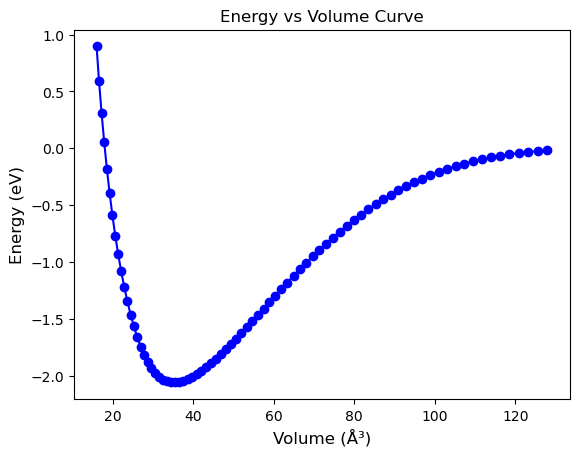

In [11]:
wf.run()

In [14]:
wf.plotting.outputs.fig.value.savefig('EV_example.png', dpi=300)

In [16]:
pf2 = PyironFlow([Workflow("Murnagha_exercise"),wf], nodes_path='./pyiron_nodes/', workflow_path='./pyiron_core_data/workflows/')

In [17]:
pf2.gui